In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [28]:
#Importing csv files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)

(668665, 15)
(286571, 14)


In [29]:
#Checking the csv
print(train.head())

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66            92887.0              23.4                     2   
1   1   38            30000.0               5.0                     1   
2   2   26            94389.0              36.8                     1   
3   3   66            73580.0              23.7                     2   
4   4   54            57898.0              50.8                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                          1.0    Male  Suburban            Sedan   
1                          4.0    Male     R

In [30]:
#Checking for null and duplicate
null = train.isnull().sum()
duplicate = test.isnull().sum()
print(null)
print(duplicate)

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64
id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
dtype: int64


In [31]:
#Separate the target variable from the input features
# X = features used by the model
# y = variable we want the model to predict

x = train.drop(columns=["Will_Buy_EV"])
y = train["Will_Buy_EV"]

In [32]:
# Check how many examples belong to each target class
# This tells us whether the classes are balanced or imbalanced

print(y.value_counts())

# Show the same distribution as percentages
print(y.value_counts(normalize=True))

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


In [33]:
# Find all columns containing categorical/text data
# Random Forest cannot directly work with string values,
# so we'll need to encode these columns later

categorical_columns = train.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')


In [34]:
#Removing the unnecessary columns
x = x.drop(columns=["id"])
x.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low


In [36]:
# Identify categorical columns containing text values
# These columns need to be converted into numerical values.

categorical_columns = x.select_dtypes(include="object").columns

# Identify numerical columns
# These can be used by Random Forest without encoding.

numerical_columns = x.select_dtypes(include="number").columns

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'],
      dtype='object')

Numerical columns:
Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level'],
      dtype='object')


In [37]:
# Convert categorical columns into one-hot encoded numerical columns.
# drop_first=True removes one category from each feature to avoid
# creating redundant columns.

x_encoded = pd.get_dummies(
    x,
    columns=categorical_columns,
    drop_first=True
)

# Check the new shape after encoding
print("Original number of features:", x.shape[1])
print("Number of features after encoding:", x_encoded.shape[1])

Original number of features: 13
Number of features after encoding: 18


In [38]:
# Check whether every feature is now numerical
print(x_encoded.dtypes.value_counts())

# Display the first five rows
x_encoded.head()

bool       11
int64       4
float64     3
Name: count, dtype: int64


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,66,92887.0,23.4,2,3,7,1.0,True,False,True,False,False,True,False,True,False,True,False
1,38,30000.0,5.0,1,2,2,4.0,True,False,False,False,True,False,False,True,False,True,False
2,26,94389.0,36.8,1,8,15,5.0,False,False,False,True,False,True,False,False,True,True,False
3,66,73580.0,23.7,2,6,9,3.0,True,False,True,False,False,False,False,True,False,True,False
4,54,57898.0,50.8,1,2,3,3.0,True,False,True,False,False,False,False,True,False,True,False


In [39]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets.
# 80% will be used to train the model.
# 20% will be used to evaluate the model.

x_train, x_valid, y_train, y_valid = train_test_split(
    x_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the resulting sizes
print("Training samples:", x_train.shape[0])
print("Validation samples:", x_valid.shape[0])

Training samples: 534932
Validation samples: 133733


In [40]:
stratify=y

In [41]:
# Check the target distribution in the training set
print("Training distribution:")
print(y_train.value_counts(normalize=True))

# Check the target distribution in the validation set
print("\nValidation distribution:")
print(y_valid.value_counts(normalize=True))

Training distribution:
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64

Validation distribution:
Will_Buy_EV
No     0.825354
Yes    0.174646
Name: proportion, dtype: float64


In [42]:
print("Original number of features:", x.shape[1])
print("Number of features after encoding:", x_encoded.shape[1])

Original number of features: 13
Number of features after encoding: 18


In [44]:
# Import the Random Forest classification model
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# n_estimators = number of decision trees in the forest
# random_state = makes our results reproducible
# n_jobs=-1 = use all available CPU cores to train faster

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest using our training data
rf_model.fit(x_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [46]:
# Generate the probability of each validation observation belonging
# to each target class.
#
# [:, 1] selects the probability of the second class.
# In our case, sklearn's classes should be ['No', 'Yes'],
# so column 1 represents the probability of "Yes".

y_valid_prob = rf_model.predict_proba(x_valid)[:, 1]

# Display a few predicted probabilities
print(y_valid_prob[:10])

# Check the class order used by the model
print("Model classes:", rf_model.classes_)

[0.13       0.03666667 0.66       0.00333333 0.         0.
 0.01666667 0.00666667 0.69       0.35333333]
Model classes: ['No' 'Yes']


In [47]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC using the actual validation labels
# and the probabilities predicted by our Random Forest.

auc_score = roc_auc_score(y_valid, y_valid_prob)

print(f"Validation ROC-AUC: {auc_score:.5f}")

Validation ROC-AUC: 0.93526


In [49]:
# Create a DataFrame containing every feature and its importance
# according to the Random Forest.

feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the 20 most important features
print(feature_importance.head(20))

                        Feature  Importance
6   Environmental_Concern_Level    0.277988
1             Annual_Income_USD    0.179747
15        Subsidy_Available_Yes    0.141740
2              Daily_Commute_km    0.102306
0                           Age    0.094997
5   Charging_Stations_Near_Work    0.062422
4   Charging_Stations_Near_Home    0.051692
3          Number_of_Cars_Owned    0.025025
7                   Gender_Male    0.013684
12       Current_Car_Type_Sedan    0.009233
11         Current_Car_Type_SUV    0.008441
16      Range_Anxiety_Level_Low    0.007569
17   Range_Anxiety_Level_Medium    0.006390
9            City_Type_Suburban    0.005378
14   Home_Charging_Possible_Yes    0.004945
13       Current_Car_Type_Truck    0.004022
10              City_Type_Urban    0.002907
8                  Gender_Other    0.001513


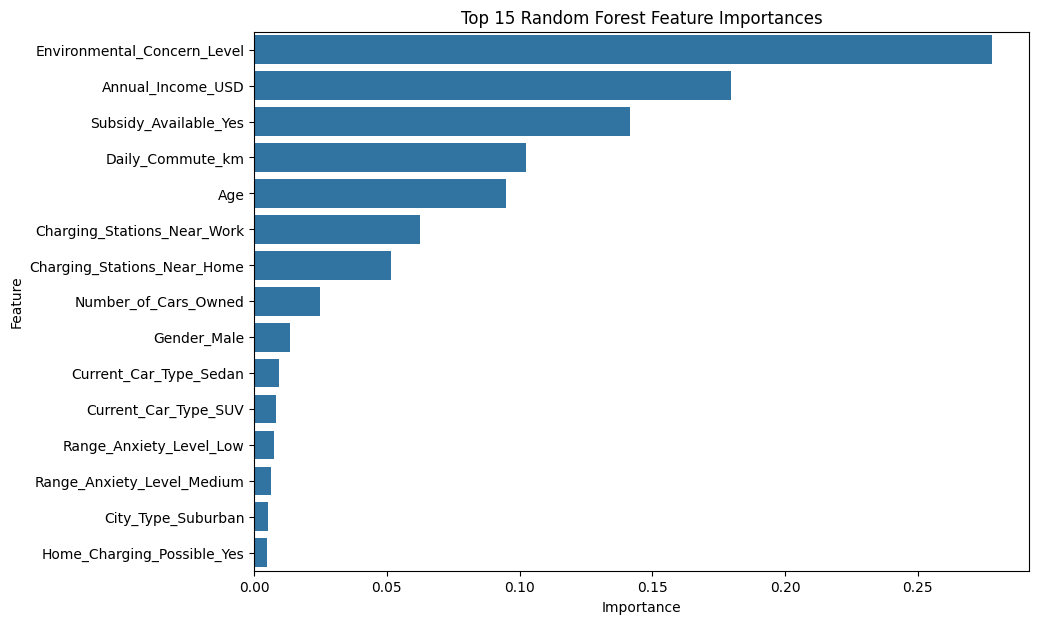

In [50]:
# Select the 15 most important features for visualization
top_features = feature_importance.head(15)

# Create a horizontal bar chart
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

# Add a title
plt.title("Top 15 Random Forest Feature Importances")

# Display the plot
plt.show()

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Create 5 stratified folds.
# Stratified means each fold keeps approximately the same
# "No" / "Yes" proportion as the original dataset.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate our Random Forest using ROC-AUC on all 5 folds.
# Each fold is used once as validation data while the other
# four folds are used for training.

cv_scores = cross_val_score(
    rf_model,
    x_encoded,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# Display the ROC-AUC score from each fold
print("ROC-AUC for each fold:")
print(cv_scores)

# Calculate the average ROC-AUC across all 5 folds
print(f"\nMean ROC-AUC: {cv_scores.mean():.5f}")

# Calculate how much the scores vary between folds
print(f"Standard Deviation: {cv_scores.std():.5f}")

ROC-AUC for each fold:
[0.93423856 0.93519239 0.93643522 0.93569714 0.93504775]

Mean ROC-AUC: 0.93532
Standard Deviation: 0.00073


In [52]:
# Display the number of features used by the model
print("Total features:", len(feature_importance))

# Display the top 20 features
print(feature_importance.head(20).to_string(index=False))

Total features: 18
                    Feature  Importance
Environmental_Concern_Level    0.277988
          Annual_Income_USD    0.179747
      Subsidy_Available_Yes    0.141740
           Daily_Commute_km    0.102306
                        Age    0.094997
Charging_Stations_Near_Work    0.062422
Charging_Stations_Near_Home    0.051692
       Number_of_Cars_Owned    0.025025
                Gender_Male    0.013684
     Current_Car_Type_Sedan    0.009233
       Current_Car_Type_SUV    0.008441
    Range_Anxiety_Level_Low    0.007569
 Range_Anxiety_Level_Medium    0.006390
         City_Type_Suburban    0.005378
 Home_Charging_Possible_Yes    0.004945
     Current_Car_Type_Truck    0.004022
            City_Type_Urban    0.002907
               Gender_Other    0.001513


In [53]:
# Create a final Random Forest model using the same configuration
# that we validated with cross-validation.

final_rf = RandomForestClassifier(
    n_estimators=300,     # Use 300 decision trees
    random_state=42,     # Keep results reproducible
    n_jobs=-1             # Use all available CPU cores
)

# Train the final model on ALL available training data.
# We no longer need X_train/X_valid because we've already
# evaluated the model using cross-validation.

final_rf.fit(x_encoded, y)

print("Final model trained successfully!")

Final model trained successfully!


In [54]:
# Make a copy of the test data so the original test DataFrame
# remains unchanged.

x_test = test.copy()

# Remove the ID because it is only an identifier and was
# removed from our training features.

x_test = x_test.drop(columns=["id"])

# Convert the categorical columns into the same one-hot encoded
# format used for the training data.

x_test_encoded = pd.get_dummies(
    x_test,
    columns=categorical_columns,
    drop_first=True
)

# Make sure test data has exactly the same columns as training data.
# If a category exists in one dataset but not the other,
# reindexing handles the difference.

x_test_encoded = x_test_encoded.reindex(
    columns=x_encoded.columns,
    fill_value=0
)

print("Training features:", x_encoded.shape[1])
print("Test features:", x_test_encoded.shape[1])

Training features: 18
Test features: 18


In [55]:
# Generate the probability that each test observation belongs
# to the "Yes" class (will buy an EV).

test_predictions = final_rf.predict_proba(
    x_test_encoded
)[:, 1]

# Display a few predictions
print(test_predictions[:10])

[0.00666667 0.04666667 0.         0.00333333 0.01666667 0.
 0.32333333 0.         0.75666667 0.00666667]


In [56]:
# Create a DataFrame in the format required by Kaggle.
# The ID must come from the original test dataset.
# Will_Buy_EV contains the predicted probability of "Yes".

submission = pd.DataFrame({
    "id": test["id"],
    "Will_Buy_EV": test_predictions
})

# Check the first few rows of our submission
print(submission.head())

       id  Will_Buy_EV
0  668665     0.006667
1  668666     0.046667
2  668667     0.000000
3  668668     0.003333
4  668669     0.016667


In [57]:
# Check the number of rows
print("Submission rows:", len(submission))

# Check for missing predictions
print("Missing predictions:", submission["Will_Buy_EV"].isna().sum())

# Check the submission columns
print("Columns:", submission.columns.tolist())

Submission rows: 286571
Missing predictions: 0
Columns: ['id', 'Will_Buy_EV']


In [59]:
# Verify that we have exactly one prediction for every test observation
print("Test rows:", len(test))
print("Submission rows:", len(submission))

Test rows: 286571
Submission rows: 286571


In [58]:
# Save the submission DataFrame as a CSV file.
# index=False prevents pandas from creating an extra index column.

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!
